<a href="https://colab.research.google.com/github/nitshar002/real-estate-pricing-model/blob/main/AdvancedProcessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importing Initial Preprocessing File

In [ ]:
user = 'group'
user = user.lower()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

train_df = pd.read_parquet(
    "/content/drive/MyDrive/IDX Housing Data/initial_train_processed.parquet"
)

test_df = pd.read_parquet(
    "/content/drive/MyDrive/IDX Housing Data/initial_test_processed.parquet"
)



Mounted at /content/drive


TYLER

In [ ]:
import geopandas as gpd

# Analyzing data with prints.
print(test_df['HighSchoolDistrict'].value_counts())
print(test_df['HighSchoolDistrict'].isna().sum())
print('Avg of NA:', train_df[train_df['HighSchoolDistrict'].isna()]['ClosePrice'].mean())
print('Avg non NA:', train_df[train_df['HighSchoolDistrict'].notna()]['ClosePrice'].mean())
print('Avg of NA:', test_df[test_df['HighSchoolDistrict'].isna()]['ClosePrice'].mean())
print('Avg non NA:', test_df[test_df['HighSchoolDistrict'].notna()]['ClosePrice'].mean())

# 2. Convert your DataFrame into a GeoDataFrame (turning Lat/Lon into spatial points)
# Make sure your columns are actually named 'Longitude' and 'Latitude'
gdf_points = gpd.GeoDataFrame(
    train_df,
    geometry=gpd.points_from_xy(train_df['Longitude'], train_df['Latitude']),
    crs="EPSG:4326" # Standard GPS coordinate system
)

# 3. Load the GeoJSON District Map you uploaded
gdf_districts = gpd.read_file('/content/drive/MyDrive/IDX Housing Data/California_School_District_Areas_2024-25.geojson')

# 4. Filter the map for only High School and Unified Districts
high_schools_gdf = gdf_districts[gdf_districts['DistrictType'].isin(['High', 'Unified'])]

# 5. Make sure both maps use the exact same coordinate system
gdf_points = gdf_points.to_crs(high_schools_gdf.crs)

# 6. Perform the Spatial Join! (This matches the point to the polygon it falls inside)
joined_data = gpd.sjoin(gdf_points, high_schools_gdf, how="left", predicate="within")

# 7. Grab the 'DistrictName' from the map and fill your empty column
# I chose to completely override the Districts because there were a lot of mismatches in formatting between original and new data,
# and borders could have been changed from year to year, so it is consistent to stay with the same dataset from the same year.
train_df['HighSchoolDistrict'] = joined_data['DistrictName']
train_df['HighSchoolDistrict'] = train_df['HighSchoolDistrict'].fillna('Out of Bounds / Premium')

# Repeating for the test dataframe
# 2. Convert your DataFrame into a GeoDataFrame (turning Lat/Lon into spatial points)
# Make sure your columns are actually named 'Longitude' and 'Latitude'
gdf_points = gpd.GeoDataFrame(
    test_df,
    geometry=gpd.points_from_xy(test_df['Longitude'], test_df['Latitude']),
    crs="EPSG:4326" # Standard GPS coordinate system
)

# 6. Perform the Spatial Join! (This matches the point to the polygon it falls inside)
joined_data = gpd.sjoin(gdf_points, high_schools_gdf, how="left", predicate="within")

# 7. Grab the 'DistrictName' from the map and fill your empty column
# I chose to completely override the Districts because there were a lot of mismatches in formatting between original and new data,
# and borders could have been changed from year to year, so it is consistent to stay with the same dataset from the same year.
test_df['HighSchoolDistrict'] = joined_data['DistrictName']
test_df['HighSchoolDistrict'] = test_df['HighSchoolDistrict'].fillna('Out of Bounds / Premium')

# Checking with prings
print(test_df.isna().sum())
print('Avg of NA:', test_df[test_df['HighSchoolDistrict'].isna()]['ClosePrice'].mean())
print('Avg non NA:', test_df[test_df['HighSchoolDistrict'].notna()]['ClosePrice'].mean())
print(test_df['HighSchoolDistrict'].value_counts())
# print(test_df['HighSchoolDistrict']['Out of Bounds / Premium'])

HighSchoolDistrict
Unknown                    2114
Los Angeles Unified         671
Other                       551
Capistrano Unified          167
Riverside Unified           141
                           ... 
Santa Paula                   1
Cypress School District       1
La Canada Unified             1
Taft Union                    1
Del Mar Union                 1
Name: count, Length: 320, dtype: int64
0
Avg of NA: nan
Avg non NA: 1145225.770758863
Avg of NA: nan
Avg non NA: 1083054.271211966
Flooring                  0
ViewYN                    0
WaterfrontYN              0
BasementYN                0
PoolPrivateYN             0
ClosePrice                0
Latitude                  0
Longitude                 0
UnparsedAddress          11
LivingArea                0
DaysOnMarket              0
CountyOrParish            0
AttachedGarageYN          0
ParkingTotal              0
YearBuilt                 0
BathroomsTotalInteger     0
City                      0
BedroomsTotal         

### Dropping Columns

Comment drops if you want to keep these columns.

After meeting, I think we should keep Lat and Longitude

In [ ]:
# 1. Calculate the average price for each district using ONLY the training data
district_price_map = train_df.groupby('HighSchoolDistrict')['ClosePrice'].mean()

# 2. Map those averages onto both your train and test sets
train_df['District_Avg_Price'] = train_df['HighSchoolDistrict'].map(district_price_map)
test_df['District_Avg_Price'] = test_df['HighSchoolDistrict'].map(district_price_map)

# Deal with "Rare" Districts
# 3. Handle "New" Districts (The Rare Fallback Method)
# Count how often each district appears in Train
district_counts = train_df['HighSchoolDistrict'].value_counts()

# Identify "Rare" Districts (e.g., appeared less than 3 times)
# Note: You can adjust this threshold (3) based on your own EDA/elbow method!

dist_stats = train_df.groupby('HighSchoolDistrict')['ClosePrice'].agg(['count', 'mean', 'std'])

# Elbow method found 3 again:
# print(dist_stats[dist_stats['count'] == 2]['std'].mean())
# print(dist_stats[dist_stats['count'] == 3]['std'].mean())
# print(dist_stats[dist_stats['count'] == 4]['std'].mean())
# print(dist_stats[dist_stats['count'] == 5]['std'].mean())
# print(dist_stats[dist_stats['count'] == 10]['std'].mean())

rare_districts = district_counts[district_counts < 3].index

# Calculate the average price of these "Rare" districts using ONLY training data
rare_district_mean = train_df[train_df['HighSchoolDistrict'].isin(rare_districts)]['ClosePrice'].mean()

print(f"Global District Mean: ${train_df['ClosePrice'].mean():,.0f}")
print(f"Rare District Mean: ${rare_district_mean:,.0f}")

# 4. Fill the missing Encoded Districts in the test set with the rare district mean
test_df['District_Avg_Price'] = test_df['District_Avg_Price'].fillna(float(rare_district_mean))

# Now you can drop the original text column!
# train_df = train_df.drop(columns=['HighSchoolDistrict'])
# test_df = test_df.drop(columns=['HighSchoolDistrict'])

Global District Mean: $1,145,226
Rare District Mean: $602,648


##Using Latitude and Longitude to generate Comps-related features -- CHARLIE

I will use a K-Nearest Neighbor algorithm to do this

In [ ]:
from sklearn.neighbors import NearestNeighbors
import pandas as pd
import numpy as np

k = 5

train_coords = train_df[['Latitude', 'Longitude']].values
knn = NearestNeighbors(n_neighbors=k + 1, metric='haversine')
knn.fit(np.radians(train_coords))
train_distances, train_indices = knn.kneighbors(np.radians(train_coords))
train_indices = train_indices[:, 1:]
train_distances = train_distances[:, 1:]

test_coords = test_df[['Latitude', 'Longitude']].values
test_distances, test_indices = knn.kneighbors(np.radians(test_coords))
test_distances = test_distances[:, :k]
test_indices = test_indices[:, :k]

print((train_distances, train_indices))

(array([[4.61928539e-05, 4.66052165e-05, 5.18043130e-05, 5.97983424e-05,
        6.15971134e-05],
       [1.04137099e-05, 1.14422604e-05, 1.54455777e-05, 4.75891277e-05,
        5.27580926e-05],
       [2.02709605e-05, 2.79837763e-05, 3.54214313e-05, 4.11807712e-05,
        4.29624609e-05],
       ...,
       [1.63603925e-05, 2.18558461e-05, 2.20760436e-05, 2.24454985e-05,
        2.89997408e-05],
       [7.18004924e-04, 8.42207510e-04, 8.88167269e-04, 9.64099124e-04,
        9.70111023e-04],
       [9.84834956e-06, 1.29136038e-05, 1.72847010e-05, 3.22962792e-05,
        3.94880415e-05]]), array([[ 11326,  99401,  51313,  84607,    671],
       [ 42905,  97593,    505,  59270,  49725],
       [ 99325,  32307,   3367,  38886,  57798],
       ...,
       [ 28433,  19502,  75029,  20951,   9317],
       [110627,  87587,  78650,  46769, 102352],
       [ 16587,  31753,  96380,  18576, 102702]]))


In [ ]:
train_comp_sqft = []
train_comp_beds = []
train_comp_baths = []

for neighbors in train_indices:
    train_comp_sqft.append(train_df.iloc[neighbors]['LotSizeSquareFeet'].mean())
    train_comp_beds.append(train_df.iloc[neighbors]['BedroomsTotal'].mean())
    train_comp_baths.append(train_df.iloc[neighbors]['BathroomsTotalInteger'].mean())

train_df['comp_avg_sqft'] = train_comp_sqft
train_df['comp_avg_beds'] = train_comp_beds
train_df['comp_avg_baths'] = train_comp_baths

test_comp_sqft = []
test_comp_beds = []
test_comp_baths = []

for neighbors in test_indices:
    test_comp_sqft.append(train_df.iloc[neighbors]['LotSizeSquareFeet'].mean())
    test_comp_beds.append(train_df.iloc[neighbors]['BedroomsTotal'].mean())
    test_comp_baths.append(train_df.iloc[neighbors]['BathroomsTotalInteger'].mean())

test_df['comp_avg_sqft'] = test_comp_sqft
test_df['comp_avg_beds'] = test_comp_beds
test_df['comp_avg_baths'] = test_comp_baths

In [ ]:
test_df.head(10)

,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,ClosePrice,Latitude,Longitude,LivingArea,DaysOnMarket,AttachedGarageYN,...,comp_avg_sqft,comp_avg_beds,comp_avg_baths,Postal_Code_Encoded,log_HOA,Home_Age^2,Bed_to_Bath,Living_Area_to_Bedrooms,Living_Area_per_Story,DistNearestRestaurantMi
0,False,False,False,False,1998000.0,37.871927,-122.029871,2045.0,0,True,...,10963.20,3.8,2.4,1.722247e+06,4.409763,3364.0,2.000000,511.250000,2045.0,1.363677
1,True,False,False,False,2214421.0,34.150680,-118.580650,3050.0,0,True,...,18352.60,4.8,5.2,1.560071e+06,0.000000,4761.0,1.000000,762.500000,1525.0,1.172980
2,False,False,False,False,1200000.0,37.306405,-121.835428,1594.0,0,True,...,6145.00,3.0,2.0,1.502140e+06,0.000000,2304.0,2.000000,398.500000,1594.0,0.501974
3,False,False,False,False,3100000.0,37.272636,-121.921351,2700.0,0,True,...,6946.00,3.0,2.2,2.140156e+06,0.000000,1.0,1.666667,540.000000,2700.0,0.210014
4,False,False,False,False,2900000.0,37.303942,-121.935424,2948.0,0,True,...,7994.20,4.0,2.4,1.641420e+06,0.000000,9.0,1.250000,589.600000,2948.0,0.218353
5,True,False,False,False,1050000.0,33.626544,-117.634791,1503.0,0,True,...,3478.00,2.4,2.4,1.300378e+06,6.371612,1681.0,1.500000,501.000000,1503.0,0.052869
6,False,False,False,False,705000.0,37.984530,-122.020961,1250.0,0,True,...,5795.00,3.4,1.8,7.794743e+05,0.000000,6084.0,3.000000,416.666667,1250.0,0.312208
7,True,False,False,False,1140000.0,33.466321,-117.066776,3574.0,0,True,...,11848.24,4.8,3.8,9.348678e+05,4.025352,400.0,1.250000,714.800000,1787.0,1.545042
8,False,False,False,False,914000.0,37.708564,-122.436143,1656.0,0,True,...,4482.80,2.6,2.0,1.098122e+06,0.000000,4356.0,1.000000,552.000000,828.0,0.392383
9,True,False,False,False,2500000.0,33.538775,-117.779450,1459.0,0,True,...,4888.60,3.0,2.2,3.177270e+06,0.000000,11664.0,1.000000,486.333333,729.5,0.157727


In [ ]:
# Drop for sure, redundant columns. Flooring is OHE manually, Zip3 is perfectly multicollinear with zipcode, which contains more data.
# Also removed PostalCode_root and PostalCode5, as PostalCode is already adjusted to be a 5 digit zipcode.
train_df = train_df.drop(columns=['Flooring', 'Zip3', 'PostalCode_root', 'PostalCode5', 'UnparsedAddress'])
test_df = test_df.drop(columns=['Flooring', 'Zip3', 'PostalCode_root', 'PostalCode5', 'UnparsedAddress'])

# Probably drop based on multicolinnearity and bias. PostalCode is related to all of these locational variables.
train_df = train_df.drop(columns=['CountyOrParish', 'City', 'StateOrProvince'])
test_df = test_df.drop(columns=['CountyOrParish', 'City', 'StateOrProvince',])

# Maybe drop. Depends how we want to evaluate YearBuilt and LivingArea
train_df = train_df.drop(columns=['YearBuiltBin', 'LivingAreaBin'])
test_df = test_df.drop(columns=['YearBuiltBin', 'LivingAreaBin'])

# # Probably keep. Use Lat/Long to fill other nulls in HighSchoolDistrict.
# # Then maybe drop Lat/Long afterwards? not sure.
# train_df = train_df.drop(columns=['Latitude', 'Longitude', 'HighSchoolDistrict'])
# test_df = test_df.drop(columns=['Latitude', 'Longitude', 'HighSchoolDistrict'])

# Realistically we should keep one or the other, Lat/Long or PostalCode for multicollinearity purposes.
# But maybe keeping BOTH is strong b/c Location is very, very important for the model.
# Tyler Math Class Note (probably OD):
# Create orthogonal polynomials with the similar vectors to create distinct, independent features and reduce error.
# Probably won't do much as this is a very very small tweak, but I might implement it bc I'm learning this content in school rn.

In [ ]:
print(train_df.isna().sum())
print(test_df.isna().sum())

print(train_df.shape)
print(test_df.shape)

ViewYN                   0
WaterfrontYN             0
BasementYN               0
PoolPrivateYN            0
ClosePrice               0
Latitude                 0
Longitude                0
LivingArea               0
DaysOnMarket             0
AttachedGarageYN         0
ParkingTotal             0
YearBuilt                0
BathroomsTotalInteger    0
BedroomsTotal            0
FireplaceYN              0
Stories                  0
MainLevelBedrooms        0
NewConstructionYN        0
GarageSpaces             0
HighSchoolDistrict       0
PostalCode               0
LotSizeSquareFeet        0
HasCarpet                0
HasVinyl                 0
HasStone                 0
HasBamboo                0
HasConcrete              0
HasBrick                 0
HasLaminate              0
HasTile                  0
HasWood                  0
HasUnknownFlooring       0
Monthly_HOA              0
District_Avg_Price       0
comp_avg_sqft            0
comp_avg_beds            0
comp_avg_baths           0
d

### PostalCode Encoding

Uncomment the block(s) you want to test in the model.

TYLER Encoding PostalCode grouped by average ClosePrice per PostalCode. Also factored in rare ZIPs, and gave them a standardized ClosePrice.

Faster Model compared to dummies, but more likely to overfit.

In [ ]:
# 1. Calculate the average price for each Zip Code in the TRAINING set
zip_code_means = train_df.groupby('PostalCode')['ClosePrice'].mean()

# 2. Map these averages to the Train set
train_df['Postal_Code_Encoded'] = train_df['PostalCode'].map(zip_code_means)

# 3. Map the SAME averages to the Test set
test_df['Postal_Code_Encoded'] = test_df['PostalCode'].map(zip_code_means)

# 4. Handle "New" Zip Codes (The Safety Net)
# If it is new in train and not in test, it is a rare Zipcode, likely a rural area.
# Count how often each zip appears in Train
zip_counts = train_df['PostalCode'].value_counts()

# Identify "Rare" Zips (e.g., appeared less than 3 times, used elbow method to decide 3)
rare_zips = zip_counts[zip_counts < 3].index

# Elbow Method
# print(len(rare_zips)/train_df.shape[0])
# print(test_df['Postal_Code_Encoded'].isna().sum()/test_df.shape[0])

# zip_stats = train_df.groupby('PostalCode')['ClosePrice'].agg(['count', 'mean', 'std'])
# # Look at the standard deviation (volatility) for low counts
# print(zip_stats[zip_stats['count'] == 2]['std'].mean())
# print(zip_stats[zip_stats['count'] == 3]['std'].mean())
# print(zip_stats[zip_stats['count'] == 4]['std'].mean())
# print(zip_stats[zip_stats['count'] == 5]['std'].mean())
# print(zip_stats[zip_stats['count'] == 10]['std'].mean())

# Calculate the average price of these "Rare" zips
rare_zip_mean = train_df[train_df['PostalCode'].isin(rare_zips)]['ClosePrice'].mean()

train_data_mean = test_df[test_df['Postal_Code_Encoded'].isna()]['ClosePrice'].mean()

print(f"Global Mean: ${train_df['ClosePrice'].mean():,.0f}")
print(f"Rare Zip Mean: ${rare_zip_mean:,.0f}")
print(f"Train Data Mean: ${train_data_mean:,.0f}")
# This gives us a more accurate representation of train data,
# without using the train data itself

# Fill the Encoded Postal Code with the rare zipcode mean.
test_df['Postal_Code_Encoded'] = test_df['Postal_Code_Encoded'].fillna(float(rare_zip_mean))

# train_df.drop(columns=['PostalCode'], inplace=True)
# test_df.drop(columns=['PostalCode'], inplace=True)

Global Mean: $1,145,226
Rare Zip Mean: $748,358
Train Data Mean: $642,786


 ZENGTAO
#Feature Engineering
I will engineer the following features:

*   Log HOA
*   Home age
*   Bed-to-bath ratio
*   Living area to bedrooms
*   Living area per story

log HOA removes the right skewness from HOA costs.

home age starts from 0 and will be easier to interpret than just the year the home was built.

A bed-to-bath ratio will directly compare the two features. A ratio closer to 1 would be more ideal.

For living area to bedrooms, perhaps a larger ratio would mean more living space per pereson and we can directly account for this

Lastly, a feature for living area per story will offer insight into the architecture and style of the house.

In [ ]:
# Examining weird, negative Monthly_HOA values in our dataframe

print(train_df["Monthly_HOA"].min())
#train_df[train_df["Monthly_HOA"] <= -1]
print((train_df["Monthly_HOA"] == -1).mean())

-1.0
0.00035846148331361794


In [ ]:
# Feature engineering code!

# Replacing the -1 HOA values with 0, then using a log transformation
train_df["Monthly_HOA"] = train_df["Monthly_HOA"].replace(-1, 0)
train_df["log_HOA"] = np.log1p(train_df["Monthly_HOA"])

test_df["Monthly_HOA"] = test_df["Monthly_HOA"].replace(-1, 0)
test_df["log_HOA"] = np.log1p(test_df["Monthly_HOA"])


# This decreased metrics a little, so I'll keep Monthly_HOA and log_HOA
'''
train_df = train_df.drop("Monthly_HOA", axis = 1)
test_df = test_df.drop("Monthly_HOA", axis = 1)
'''


# Engineering a home age feature from year built
train_df["Home_Age^2"] = (2026 - train_df["YearBuilt"])**2

test_df["Home_Age^2"] = (2026 - test_df["YearBuilt"])**2

# Engineering Bed-to-Bath ratio
train_df["Bed_to_Bath"] = np.where(
    train_df["BathroomsTotalInteger"] > 0,
    train_df["BedroomsTotal"] / train_df["BathroomsTotalInteger"],
    np.nan
)

test_df["Bed_to_Bath"] = np.where(
    test_df["BathroomsTotalInteger"] > 0,
    test_df["BedroomsTotal"] / test_df["BathroomsTotalInteger"],
    np.nan
)

median_ratio = train_df["Bed_to_Bath"].median()

train_df["Bed_to_Bath"].fillna(median_ratio, inplace=True)
test_df["Bed_to_Bath"].fillna(median_ratio, inplace=True)


# Engineering living area to bedrooms ratio
train_df["Living_Area_to_Bedrooms"] = np.where(
    train_df["BedroomsTotal"] > 0,
    train_df["LivingArea"] / train_df["BedroomsTotal"],
    np.nan
)

test_df["Living_Area_to_Bedrooms"] = np.where(
    test_df["BedroomsTotal"] > 0,
    test_df["LivingArea"] / test_df["BedroomsTotal"],
    np.nan
)

median_ratio = train_df["Living_Area_to_Bedrooms"].median()

train_df["Living_Area_to_Bedrooms"].fillna(median_ratio, inplace=True)
test_df["Living_Area_to_Bedrooms"].fillna(median_ratio, inplace=True)


# Engineering living area per story
train_df["Living_Area_per_Story"] = train_df["LivingArea"] / train_df["Stories"]

test_df["Living_Area_per_Story"] = test_df["LivingArea"] / test_df["Stories"]

/tmp/ipykernel_599/3863626780.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df["Bed_to_Bath"].fillna(median_ratio, inplace=True)
/tmp/ipykernel_599/3863626780.py:39: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

### Location seems to be the most important factor for housing price prediction. We could also factor in **distance to the nearest restaurant**. Also maybe distance to coast would be great.

## Charlie -- Updated restaurant feature

In [ ]:
restaurants = pd.read_parquet(
    f"/content/drive/MyDrive/IDX Housing Data/zengtao_restaurants.parquet"
)


# Houses from train_df
houses_train = train_df[["Latitude","Longitude"]]
houses_test = test_df[["Latitude","Longitude"]]

# Convert coordinates to radians so we can find distance
coords_houses_train = np.radians(train_df[["Latitude","Longitude"]].values)
coords_houses_test = np.radians(test_df[["Latitude","Longitude"]].values)
coords_rest = np.radians(restaurants[["lat","lon"]].values)

# Build spatial index
from sklearn.neighbors import BallTree
tree = BallTree(coords_rest, metric="haversine")

# Query nearest restaurant for TRAIN
dist_train, idx_train = tree.query(coords_houses_train, k=1)

# Convert radians -> miles
train_df["DistNearestRestaurantMi"] = dist_train.flatten() * 3958.8


# Query nearest restaurant for TEST
dist_test, idx_test = tree.query(coords_houses_test, k=1)

# Convert radians -> miles
test_df["DistNearestRestaurantMi"] = dist_test.flatten() * 3958.8

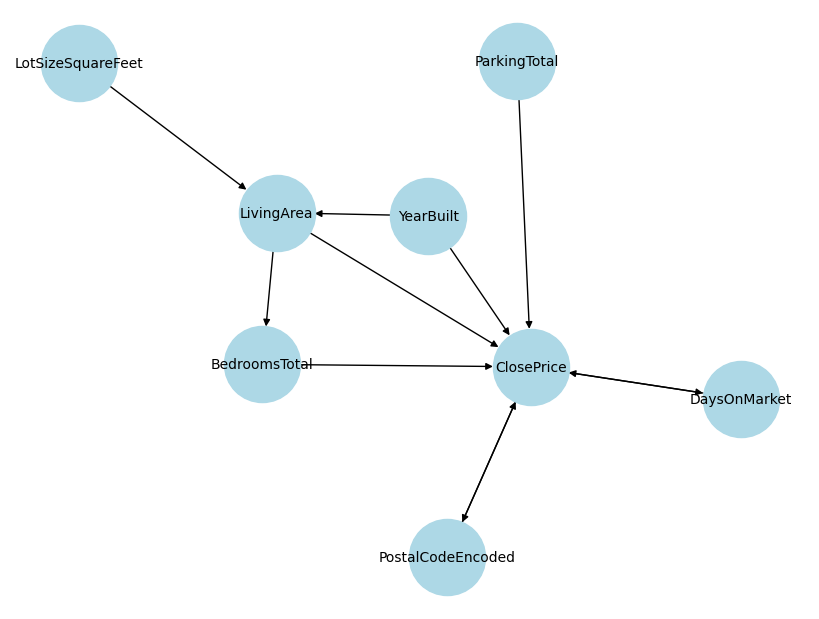

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

edges = [
    ("LotSizeSquareFeet", "LivingArea"),
    ("LivingArea", "ClosePrice"),
    ("YearBuilt", "LivingArea"),
    ("ClosePrice", "PostalCodeEncoded"),
    ("PostalCodeEncoded", "ClosePrice"), # This is a strong bidirectional relationship. We could engineer more features related to location
    ("YearBuilt", "ClosePrice"),
    ("LivingArea", "BedroomsTotal"),
    ("LivingArea", "ClosePrice"),
    ("BedroomsTotal", "ClosePrice"),
    ("ParkingTotal", "ClosePrice"),
    ("DaysOnMarket", "ClosePrice"),
    ("ClosePrice", "DaysOnMarket") #But we don't know DaysOnMarket in a realistic prediction scenario. Potential target leakage?
]

G = nx.DiGraph()
G.add_edges_from(edges)

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="lightblue", font_size=10)
plt.show()

Start Tyler

Generating maps to use in app.py to map back to the original values.

In [ ]:
import json

# --- 1. Export Zip Codes ---
# Convert the Series you already made into a dictionary
zip_dict = zip_code_means.to_dict()

# Add the rare mean as a fallback key!
zip_dict['Unknown'] = float(rare_zip_mean)

# print(zip_dict)

# Save it
with open(f'/content/drive/MyDrive/IDX Housing Data/{user}_AdvancedProcessingAndModeling/models/zip_code_map.json', 'w') as f:
    json.dump(zip_dict, f)

# --- 2. Export Districts ---
# Convert the Series you already made into a dictionary
district_dict = district_price_map.to_dict()

# Add the rare mean as a fallback key!
district_dict['Unknown'] = float(rare_district_mean)

# Save it
with open(f'/content/drive/MyDrive/IDX Housing Data/{user}_AdvancedProcessingAndModeling/models/district_map.json', 'w') as f:
    json.dump(district_dict, f)

print("✅ Dictionaries successfully saved to the models folder!")

# --- Now you can safely drop them! ---
train_df = train_df.drop(columns=['HighSchoolDistrict', 'PostalCode'], errors='ignore')
test_df = test_df.drop(columns=['HighSchoolDistrict', 'PostalCode'], errors='ignore')

✅ Dictionaries successfully saved to the models folder!


End Tyler

### Exporting Train and Test DF to go into Modeling

In [ ]:
print(train_df.isna().sum())
print(test_df.isna().sum())

print(train_df.shape)
print(test_df.shape)

In [ ]:
# user defined in the first box of the file.
train_path = f"/content/drive/MyDrive/IDX Housing Data/{user}_AdvancedProcessingAndModeling/{user}_train_processed.parquet"
test_path = f"/content/drive/MyDrive/IDX Housing Data/{user}_AdvancedProcessingAndModeling/{user}_test_processed.parquet"

train_df.to_parquet(train_path, index=False)
test_df.to_parquet(test_path, index=False)